# **03 Qdrant로 만드는 기본 RAG**

### 학습 내용
1. PDF 문서 텍스트 추출
2. LangChain Document 형식으로 변환
3. Qdrant 벡터스토어 구축
4. 유사도 검색 테스트
5. 검색 기반 RAG 답변 생성
6. 특수 형식 PDF 처리 (좌표 기반 분할)

**사용 데이터:**
- 2026 주요업무계획.pdf
- 2026 달라지는 천안 새로운 변화.pdf

## 0. 환경 변수 설정

In [1]:
import os
from dotenv import load_dotenv

load_dotenv(dotenv_path='./.env')

if os.environ.get("OPENAI_API_KEY"):
    print("API Key가 설정되었습니다.")

API Key가 설정되었습니다.


In [2]:
# .env 파일 로드
load_dotenv()

# API 키 확인
api_key = os.getenv("OPENAI_API_KEY")

if api_key:
    print("OPENAI_API_KEY가 정상적으로 로드되었습니다.")
    print("API Key ?? ???? ????.")
else:
    print("OPENAI_API_KEY를 찾을 수 없습니다.")
    print(".env 파일을 생성하고 OPENAI_API_KEY를 설정해주세요.")

OPENAI_API_KEY가 정상적으로 로드되었습니다.
API Key: sk-proj-yw...K00A


## 1. LLM 초기화

In [3]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("gpt-5.4-mini")

## 2. PDF 1: 2026 주요업무계획 처리

### 2-1. 텍스트 추출 및 확인

In [4]:
import fitz  # PyMuPDF

file_path = "../datasets/2026 주요업무계획.pdf"

doc = fitz.open(file_path)
print(f"총 {len(doc)}페이지 로드 완료")

총 481페이지 로드 완료


In [5]:
page = doc[8]
text = page.get_text("text", sort=True)
print("="*80)
print(text)
print("="*80)

doc.close()

 03   2026      시정운영 방향

 3대 핵심가치





 7 대 역점과제



▸ AI 기반 스마트 도시 인프라 구축 및 미래혁신 AI 거점 도시 브랜딩 강화
▸ 미래 전략산업 (반도체 , 미래모빌리티등) 집중 육성 및 천안형 스타트업 육성

✔ 천안시 거점형 스마트도시 조성        ✔ 스마트그린산단 AX 실증산단 구축사업
✔ 천안 중부권 AI 컴퓨팅센터 구축        ✔ 천안형 스타트업 생태계 스케일업 추진
✔ 천안아산 연구개발특구 내 MICE 산업 기본구상 및 사업화방안 연구



▸ 기업투자유치 강화, 글로벌 시장 진출 지원 등 기업지원 정책 다변화 도모
▸전통시장 및 골목상권 강화지역,   내 소비 활성화 등 실효성 있는 경제 정책 실현

✔ “유치의 모든 것을 배달합니다”, 투자유치 DELIVERY ✔ Welcome 온보딩 (Onboarding)! 기업 정착 지원
✔ 중소기업 ESG 경영 컨설팅 지원     ✔ 2026 C-TRADE 해외바이어 초청 수출상담회
✔ 우리동네 상권 UP 프로젝트        ✔ 흩어져 있는 카드포인트천안사랑카드로,        한데모아 알뜰소비



▸ 100 만 미래도시 천안을 대비한 도로교통도시·      ·   인프라 구축 및 균형발전 도모
▸ AI 기반 도로교통체계·     구축 및 대중교통 편의 시스템 확충

✔ 2040 천안 도시기본계획 수립        ✔ 천안북부 Next Hub 성환 혁신지구 도시재생사업
✔ 천안역 증개축                ✔ 성황동불당동~    연결도로 신설 및 확장공사
✔ AI 신호제어 꼬리물기 차단 시스템 설치   ✔ 시내버스 준공영제 도입 추진


                                                 - 7 -


### 2-2. LangChain Document 형식으로 변환

LangChain에서 문서를 다루는 표준 형식은 `Document` 클래스입니다.

**Document 구조:**
```python
from langchain_core.documents import Document

document = Document(
    page_content="문서의 실제 내용",
    metadata={"source": "파일명", "page": 1}
)
```

In [6]:
from langchain_core.documents import Document
import fitz

file_path = "../datasets/2026 주요업무계획.pdf"

doc = fitz.open(file_path)
docs_plan = []

for page_num in range(len(doc)):
    page = doc[page_num]
    text = page.get_text("text", sort=True)

    # 빈 페이지는 스킵
    if len(text.strip()) < 10:
        # print(page_num, text.strip())
        continue

    # LangChain Document 형식으로 변환
    docs_plan.append(
        Document(
            page_content=text,
            metadata={
                "source": "2026 주요업무계획.pdf",
                "page": page_num + 1
            }
        )
    )

doc.close()

print(f"총 {len(docs_plan)}개의 Document 생성 완료")
print(f"\n첫 번째 문서 메타데이터: {docs_plan[0].metadata}")
print(f"첫 번째 문서 길이: {len(docs_plan[0].page_content)}자")

총 423개의 Document 생성 완료

첫 번째 문서 메타데이터: {'source': '2026 주요업무계획.pdf', 'page': 3}
첫 번째 문서 길이: 1279자


In [8]:
# Document 객체 확인
print(f"Document 내용 샘플:")
print(f"Source: {docs_plan[10].metadata['source']}")
print(f"Page: {docs_plan[10].metadata['page']}")
print(f"\nContent:\n{docs_plan[10].page_content}")

Document 내용 샘플:
Source: 2026 주요업무계획.pdf
Page: 22

Content:
 Ⅳ 주요 업무

❶ 계속 시민과 함께 소통하고 공감하는 「천안사랑 소식지제작」
  -  ( 기  간) 2026. 1. ~ 12. 아

  -  ( 소요예산 ) 400 백만원 ( 시비)

  -  (주요내용)

    ‣ 다양한 분야의 정보를 흥미롭게 제공하여시민 공감대 확산

    ‣ 시대적 흐름에 맞춰 지면 발행부수를 축소하고 모바일 앱 및 온라인 플랫폼

         (시홈페이지카카오톡채널의,                    ) 비중 확대


❷ 계속 생생한 소식을 전하는 「천안뉴스제작」
  - (기  간) 2026. 1. ~ 12.

  - (소요예산) 210 백만원 ( 시비)

  - (주요내용)

    ‣ 영상뉴스 제작을 통해 시정에 대한 시민의 이해와 접근성을 강화

    ‣ [신규] 시정 전반의 주요 내용과 성과를 심층적으로 전달하는 ‘월간뉴스’제작

     * 홍보모니터 57개소 송출


❸ 계속 시민에게 더 가까이, 시정홍보 콘텐츠 새단장

  -  ( 사업기간 ) 2026. 1. ~ 6.

  -  ( 소요예산 ) 20백만원 ( 시비)

  -  ( 주요내용 )

    ‣ 시정홍보 대표 이미지를 제작해 시민게시판·청사 홍보판 등 전면 교체

    ‣ 민선기9 시정비전 및 핵심과제를 반영한 맞춤형 시정 홍보영상 콘텐츠 제작


❹ 계속신규 개편 누리집 콘텐츠 관리 교육
  - (기  간) 2026. 1. ~ 2.

  - (소요예산비예산)

  - (주요내용)

    ‣ 새롭게 개편될 홈페이지의 콘텐츠관리시스템(CMS) 사용법 교육 및 사용 시

   유의사항유지보수,     요청방법 등 전달

    ‣ 누리집 콘텐츠의 신속정확한‧    정보 제공으로 시정 신뢰도 향상

  - (추진계획신규)   누리집 오픈(‘26.1.) ➠ 콘텐츠 관리 교육(‘26.1.) ➠ 현행화(‘26.2.)




                

## 3. Qdrant 벡터스토어 구축

**벡터스토어(Vector Store):**
- 문서를 벡터(임베딩)로 변환하여 저장
- 의미적 유사도 기반 검색 가능

**Qdrant:**
- 고성능 오픈소스 벡터 데이터베이스
- 로컬 파일 기반 저장 지원

[OpenAI 임베딩 모델 text-embedding-3-large](https://developers.openai.com/api/docs/models/text-embedding-3-large)

In [9]:
from langchain_qdrant import QdrantVectorStore
from langchain_openai import OpenAIEmbeddings
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

# Qdrant 클라이언트 생성
client = QdrantClient(path="./qdrant_db") # 로컬 디스크 저장

# 임베딩 함수 초기화
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

collection_name = "cheonan_docs"

try:
    client.create_collection(
        collection_name=collection_name,
        vectors_config=VectorParams(
            size=3072,  # text-embedding-3-large의 벡터 차원
            distance=Distance.COSINE  # 코사인 유사도
        )
    )
except Exception as e:
    print(f"컬렉션이 이미 존재하거나 오류 발생: {e}")

# 벡터스토어 초기화
vectorstore = QdrantVectorStore(
    client=client,
    collection_name=collection_name,
    embedding=embeddings
)

### 3-1. 문서 추가 (임베딩 생성)

`add_documents()` 메서드를 사용하여 문서를 벡터스토어에 추가합니다.
내부적으로 각 문서를 임베딩으로 변환하여 저장합니다.

In [10]:
from uuid import uuid4

# 문서 추가 (임베딩 생성, 시간이 다소 소요될 수 있음)
vectorstore.add_documents(documents=docs_plan)

print(f"\n{len(docs_plan)}개의 문서가 벡터스토어에 추가되었습니다.")


423개의 문서가 벡터스토어에 추가되었습니다.


In [11]:
# 저장된 문서 수 확인
collection_info = client.get_collection(collection_name)
print(f"벡터스토어에 저장된 문서 수: {collection_info.points_count}")

벡터스토어에 저장된 문서 수: 423


## 4. 유사도 검색 테스트

이제 벡터스토어에서 질문과 유사한 문서를 검색해봅시다.

[예시 질문]
- 천안시의 임산부 지원
- 천안시의 환경 조성사업
- 민방위 체험교육 일정

In [12]:
query = "천안시의 환경 조성사업"

In [13]:
# 유사도 검색 (k=3: 가장 유사한 문서 3개 반환)
results = vectorstore.similarity_search(query, k=3)

print(f"검색 쿼리: {query}")
print(f"검색 결과: {len(results)}개의 문서 반환\n")

for i, result in enumerate(results, start=1):
    print(f"\n[관련 문서 {i}]")
    print(f"출처: {result.metadata.get('source', '?')}")
    print(f"페이지: {result.metadata.get('page', '?')}")
    print(f"내용: {result.page_content}")
    print("-" * 80)

검색 쿼리: 천안시의 환경 조성사업
검색 결과: 3개의 문서 반환


[관련 문서 1]
출처: 2026 주요업무계획.pdf
페이지: 359
내용: Ⅰ 녹색 복합문화공간 「천안정원 」 조성            핵심  계속

 사 업 개 요

❍  ( 사업기간 ) 2023. 7. ~ 2028. 12.

❍  ( 대 상 지) 서북구 성환읍 대홍리 147-49 번지 일원

❍  ( 사 업 비) 27,200백만원( 도비1,800 시비25,400)

❍  ( 사 업 량) 237,307㎡

❍  ( 주요내용 ) 주제정원 5개소커뮤니티센터야영장주차장,                        ,             ,    등 조성


 추 진 계 획

❍ 토지매입 및 실시설계(‘26. 1. ~ ’27. 1.) ➠ 착공(‘27. 3.) ➠ 준공(‘28. 12.)


 기 대 효 과

❍ 정원문화 체험 공간 제공 및 정원 치유를 통한 시민 삶의 질 만족도 향상

❍ 지역경제 활성화 및 일자리 창출을 통해 지역 균형발전에 기여


Ⅱ 목재친화도시 목조전망대 조성사업                 신규

 사 업 개 요

❍  ( 사업기간 ) 2026. 1. ~ 2029. 12.

❍  ( 대 상 지) 천안시 동남구 안서동 466-3 번지 일원( 천호지공원)

❍  ( 사 업 비) 13,000백만원( 국비6,500 시비6,500)

❍  ( 사 업 량) 목조전망대 건축물지상(     4 층), 목재친화거리

❍  ( 주요내용 ) 국산 목재 활성화로 천안시 탄소중립 실현국가,    NDC(온실가스감축)

       목표에 기여 및 안서동 대학로 거리조성사업과 연계


 추 진 계 획

❍ 토지매입 및 실시설계(‘26. ~ ‘27.) ➠ 착공(‘28.) ➠ 준공(‘29.)


 기 대 효 과

❍ 국산목재산업 홍보 ·교육천안시,    탄소중립목표 달성

❍ 안서동 대학로 거리조성사업 연계한 시설· 공간 확충안서음센터(    e    연계 )




                  

### 4-1. similarity_search_with_score() - 점수와 함께 검색

In [14]:
# 유사도 점수와 함께 검색
results_with_score = vectorstore.similarity_search_with_score(query, k=3)

print(f"검색 쿼리: {query}\n")

for i, (doc, score) in enumerate(results_with_score, start=1):
    print(f"\n[관련 문서 {i}] - 유사도 점수: {score:.4f}")
    print(f"출처: {doc.metadata.get('source', '?')}")
    print(f"페이지: {doc.metadata.get('page', '?')}")
    print(f"내용: {doc.page_content}")
    print("-" * 80)

검색 쿼리: 천안시의 환경 조성사업


[관련 문서 1] - 유사도 점수: 0.6495
출처: 2026 주요업무계획.pdf
페이지: 359
내용: Ⅰ 녹색 복합문화공간 「천안정원 」 조성            핵심  계속

 사 업 개 요

❍  ( 사업기간 ) 2023. 7. ~ 2028. 12.

❍  ( 대 상 지) 서북구 성환읍 대홍리 147-49 번지 일원

❍  ( 사 업 비) 27,200백만원( 도비1,800 시비25,400)

❍  ( 사 업 량) 237,307㎡

❍  ( 주요내용 ) 주제정원 5개소커뮤니티센터야영장주차장,                        ,             ,    등 조성


 추 진 계 획

❍ 토지매입 및 실시설계(‘26. 1. ~ ’27. 1.) ➠ 착공(‘27. 3.) ➠ 준공(‘28. 12.)


 기 대 효 과

❍ 정원문화 체험 공간 제공 및 정원 치유를 통한 시민 삶의 질 만족도 향상

❍ 지역경제 활성화 및 일자리 창출을 통해 지역 균형발전에 기여


Ⅱ 목재친화도시 목조전망대 조성사업                 신규

 사 업 개 요

❍  ( 사업기간 ) 2026. 1. ~ 2029. 12.

❍  ( 대 상 지) 천안시 동남구 안서동 466-3 번지 일원( 천호지공원)

❍  ( 사 업 비) 13,000백만원( 국비6,500 시비6,500)

❍  ( 사 업 량) 목조전망대 건축물지상(     4 층), 목재친화거리

❍  ( 주요내용 ) 국산 목재 활성화로 천안시 탄소중립 실현국가,    NDC(온실가스감축)

       목표에 기여 및 안서동 대학로 거리조성사업과 연계


 추 진 계 획

❍ 토지매입 및 실시설계(‘26. ~ ‘27.) ➠ 착공(‘28.) ➠ 준공(‘29.)


 기 대 효 과

❍ 국산목재산업 홍보 ·교육천안시,    탄소중립목표 달성

❍ 안서동 대학로 거리조성사업 연계한 시설· 공간 확충안서음센터(    e    연계 )




                  

## 5. 검색 기반 RAG 답변 생성

**RAG 흐름:**
1. 질문으로 관련 문서 검색
2. 검색된 문서를 컨텍스트로 구성
3. PromptTemplate 사용하여 프롬프트 생성
4. LLM으로 답변 생성

In [15]:
from langchain_core.prompts import PromptTemplate
from IPython.display import Markdown, display

template = """
당신은 도움이 되는 AI 어시스턴트입니다.
주어진 정보를 바탕으로 사용자의 질문에 정확하고 친절하게 답변하세요.
또한, 답변에 참고한 문서의 출처와 페이지 번호를 명시하세요.

<context>
{context}
</context>

<question>
{question}
</question>
"""

prompt_template = PromptTemplate(
    input_variables=["context", "question"],
    template=template
)

In [17]:
# 1단계: 질문 정의
question = "천안시 버스에 관련된 계획은 무엇인가요?"

# 2단계: 관련 문서 검색
retrieved_docs = vectorstore.similarity_search(question, k=3)

# 3단계: 검색된 문서를 컨텍스트로 구성
context_parts = []
for doc in retrieved_docs:
    source = doc.metadata.get("source", "?")
    page_num = doc.metadata.get("page", "?")
    context_parts.append(f"[출처: {source}, 페이지: {page_num}]\n{doc.page_content}")

context = "\n\n---\n\n".join(context_parts)

print(f"검색된 문서 수: {len(retrieved_docs)}")
print(f"컨텍스트 길이: {len(context)}자")
print(f"\n질문: {question}")
print("="*80)
print("검색된 문서 컨텍스트:")
print(context)
print("\n" + "="*80)

# 4단계: 프롬프트 생성 및 답변
formatted_prompt = prompt_template.format(
    context=context,
    question=question
)

response = llm.invoke(formatted_prompt)

print("\n답변:")
display(Markdown(response.content))

검색된 문서 수: 3
컨텍스트 길이: 3101자

질문: 천안시 버스에 관련된 계획은 무엇인가요?
검색된 문서 컨텍스트:
[출처: 2026 주요업무계획.pdf, 페이지: 243]
Ⅲ 풍세천안아산역~      운행 시내버스 노선 신설           신규

 사 업 개 요

❍  ( 사업기간 ) 2026년 상반기 ~

❍  ( 사 업 량) 1 대

❍  ( 주요내용 )

   - 운수종사자 부족 및 차량 수급 한계
  → 現 천안아산을~   운행하는 산동지선(800번대) 폐지를 통한 노선 신설

    ※ 아산시에서 폐지지역 시내버스 투입예정(2026. 3.)

   - 시내버스 노선 신설을 통한 대중교통 이용 편의향상 및 접근성 증대


 추 진 계 획

❍ 운수사 협의(‘25. 11. ~ 12.)

   - 노선 운행경로 및 운행횟수 결정
   ※ 기종점․   운행시간 및 근로기준법주(  52 시간 근무), 법적휴게시간 등 고려
❍ 아산시 협의 및 통보(‘25. 12. ~ ’26. 2.)

   - 아산지역 시내버스 이용자 민원 최소화를 위한 아산시 자구책 마련
    ※ 산동방면 운행노선 폐지에 대한 사전 대책 강구 공문 발송(‘24. 8월)

   - 여객자동차운송사업 변경( 노선폐지 ) 일자 등 관련 사항 통보

❍ 신설 노선 운송개시 홍보 (’26. 상반기)





                                               - 241 -

---

[출처: 2026 주요업무계획.pdf, 페이지: 226]
Ⅳ 병천고병천중앙아파트시도~                (   22호선회전교차로)      설치공사     신규

 사 업 개 요

❍  ( 사업기간 ) 2026. 1. ~ 2027. 9.
❍  ( 사 업 비) 850백만원 ( 도비300 시비 550)
❍  ( 사 업 량) 회전교차로 설치 1개소
❍  (주요내용) 병천중앙아파트 앞  (병천면 탑원리 107-6 일원 ) 회전교차로를
       설치하여 버스회차공간 확보 및 

천안시 버스와 관련된 주요 계획은 다음과 같습니다.

1. **풍세천안아산역~ 운행 시내버스 노선 신설**
   - 기존 천안아산을 운행하던 산동지선(800번대) 폐지를 통해 **시내버스 노선을 새로 신설**합니다.
   - 운수종사자 부족과 차량 수급 한계를 고려한 조치이며, **대중교통 이용 편의와 접근성 향상**이 목적입니다.  
   - **출처:** 2026 주요업무계획.pdf, **페이지 243**

2. **남부권 시내버스 공영차고지 조성사업**
   - 시내버스 공영차고지 1개소를 조성하는 사업입니다.
   - 사업기간은 **2023년 ~ 2028년**이며, 버스 운영 기반을 강화하는 내용입니다.  
   - **출처:** 2026 주요업무계획.pdf, **페이지 243**

3. **태양광 기반 저전력 버스정보안내단말기 구축**
   - 태양광을 활용한 저전력 **버스정보안내단말기 10개소**를 설치합니다.
   - 친환경 기반 구축과 탄소 저감이 기대효과입니다.  
   - **출처:** 2026 주요업무계획.pdf, **페이지 243**

4. **초정밀 버스정보 시스템 구축**
   - 버스정보, 스탑앱 구축 및 버스정보시스템 고도화를 추진합니다.
   - 시내버스 이용 만족도 향상을 목표로 합니다.  
   - **출처:** 2026 주요업무계획.pdf, **페이지 243**

5. **병천고병천중앙아파트시도~(22호선 회전교차로) 설치공사**
   - 버스 회차공간 확보와 교통흐름 개선을 위해 회전교차로를 설치합니다.
   - 버스노선 확장과 학생·주민 편의 확보에 도움이 되는 사업입니다.  
   - **출처:** 2026 주요업무계획.pdf, **페이지 226**

원하시면 제가 이 내용을 **“신설 노선 / 인프라 구축 / 버스정보시스템”**처럼 분류해서 더 보기 쉽게 정리해드릴게요.

### 5-1. RAG 함수로 구현하기

In [18]:
def rag_answer(question: str, k: int = 3) -> str:
    """
    질문을 받아서 관련 문서를 검색하고 LLM 답변을 반환

    Args:
        question: 사용자 질문
        k: 검색할 문서 개수

    Returns:
        LLM 답변
    """
    # 1. 문서 검색
    retrieved_docs = vectorstore.similarity_search(question, k=k)

    # 2. 컨텍스트 구성
    context_parts = []
    for doc in retrieved_docs:
        source = doc.metadata.get("source", "?")
        page_num = doc.metadata.get("page", "?")
        context_parts.append(f"[출처: {source}, 페이지: {page_num}]\n{doc.page_content}")

    context = "\n\n---\n\n".join(context_parts)

    print("검색된 문서 컨텍스트:")
    print(context)
    print("\n" + "="*80)

    # 3. 프롬프트 생성
    formatted_prompt = prompt_template.format(
        context=context,
        question=question
    )

    # 4. LLM 답변 생성
    response = llm.invoke(formatted_prompt)
    return response.content

In [21]:
question = "천안시의 호두과자 제일 맛있는 곳 알려줘?"
answer = rag_answer(question)

print(f"질문: {question}\n")
display(Markdown(answer))

검색된 문서 컨텍스트:
[출처: 2026 주요업무계획.pdf, 페이지: 213]
정책
목표    식품산업의 경쟁력 강화, 바른 먹거리 환경구축




  세부전략
❍ 『2026 빵빵데이 천안의』  복합문화축제로 도약
❍ 농업분야 및 학교급식 탄소중립 실천을 위한 농축산물 소비 공급 확대
❍ 일상속 식중독으로부터 안전한 식중독 예방 및 식품안전관리 강화
❍ 농촌융복합산업의 전략적 육성 지원




  주요업무
❶ 핵심복합문화축제로 도약하는 『 2026 빵빵데이 천안』
❷ 핵심가족과 함께하는 『쌀맛나는 천안삼거리 떡 페스티벌』
❸ 핵심학교급식 저탄소 농축산물·    소비 및 공급 확대
❹ 신규더 머물고 싶은 안심 숙박업소 만들기
❺ 신규 2026년 충남식품산업박람회 개최
❻ 계속일상속 식중독으로부터 안전한 식문화 환경 정착
❼ 계속농촌융복합산업 육성 보조사업 지원
❽ 계속민생 6대분야 테마별   시기별 기획 점검





                                               - 211 -

---

[출처: 2026 주요업무계획.pdf, 페이지: 214]
Ⅰ 복합문화축제로 도약하는 「2026 빵빵데이 천안」    핵심  계속

 사 업 개 요

❍  ( 사업기간 ) 2026. 1. ~ 12.
❍  ( 사 업 비) 450백만원 ( 도비100 시비 350)
❍  ( 주요내용 )
 - 제과업계 및 지역 농축산기업대학이,         ,    함께 만들어가는 빵산업 기반 구축
 - 천안의 우수한 빵 자원을 기반으로 문화관광과 연계한‘빵빵데이 천안’개최

 추 진 계 획

❍ 관광외식숙박,         ,   등과 연계된 ‘ 빵지순례 모바일 스탬프투어’ 개발
  - 사한국외식업중앙회천안시지부사대한숙박업중앙회천안시지회)                                                ,     )             등과 상생 협업
❍ ‘ 빵빵데이 천안 ’과 MICE 연계를 통한 축제 발전 방안 모색
 -‘ 빵의 도시

천안시 **“호두과자 제일 맛있는 곳”**은 문서에 **직접 언급되어 있지 않아서**, 특정 업소를 공식적으로 추천드리기는 어렵습니다. 다만 제공된 자료를 보면 천안시는 **빵 산업과 지역 제과 자원**을 활용해 「**2026 빵빵데이 천안**」을 복합문화축제로 키우고, **“빵의 도시 천안” 브랜드 확립**을 추진하고 있습니다.  
즉, 천안의 대표 빵 문화와 제과업계가 함께 성장하는 방향을 추진 중이라고 볼 수 있습니다.

- 참고 문서: **2026 주요업무계획.pdf**
  - **페이지 213**: 식품산업 경쟁력 강화, 「2026 빵빵데이 천안」 복합문화축제 도약
  - **페이지 214**: 「2026 빵빵데이 천안」 사업 개요 및 기대효과, “빵의 도시 천안” 브랜드 확립

원하시면 제가 이어서  
1) **천안 호두과자 유명한 곳을 일반 정보 기준으로** 추천해드리거나,  
2) **천안 빵지순례 코스**처럼 정리해드릴게요.

## 6. PDF 2: 2026 달라지는 천안 새로운 변화 처리

이 PDF는 가로형이고, 하나의 페이지에 2페이지 분량이 들어있습니다.
좌표 기반으로 내용을 나누어 추출합니다.

### 6-1. 페이지 확인 및 좌표 분할 전처리

In [22]:
import fitz

file_path2 = "../datasets/2026 달라지는 천안 새로운 변화.pdf"

doc2 = fitz.open(file_path2)
print(f"총 {len(doc2)}페이지 로드 완료")

총 51페이지 로드 완료


In [23]:
page = doc2[2]
rect = page.rect
print(f"\n페이지 크기: 너비={rect.width:.2f}, 높이={rect.height:.2f}")
print(f"가로형 여부: {rect.width > rect.height}")

# 전체 텍스트 추출 테스트
text = page.get_text("text", sort=True)
print(f"\n전체 텍스트 길이: {len(text)}자")
print(f"\n첫 500자:\n{text[:500]}")

doc2.close()


페이지 크기: 너비=1190.55, 높이=765.35
가로형 여부: True

전체 텍스트 길이: 5483자

첫 500자:
CONTENTS




               새로운 천안 | 신규 조성 공간                   05                                       대중교통 환급 지원 (K-패스) 사업 확대                              36

                                                                                                   불당동 통학환경 개선을 위한 시내버스 노선 신설                       38
                     두정동 공영주차장 조성                                        06

                     성정시장 주차장 추가 조성                                       07                                  


### 6-2. 좌표 기반 텍스트 분할 추출

페이지를 좌우로 나누어 텍스트를 추출합니다.

In [25]:
from langchain_core.documents import Document
import fitz

file_path2 = "../datasets/2026 달라지는 천안 새로운 변화.pdf"

doc2 = fitz.open(file_path2)
docs_change = []

for page_num in range(len(doc2)):
    page = doc2[page_num]
    rect = page.rect

    # 페이지를 좌우로 분할
    mid_x = rect.width / 2

    # 왼쪽 절반 추출
    left_rect = fitz.Rect(0, 0, mid_x, rect.height) # fitz.Rect(시작X, 시작Y, 끝X, 끝Y)
    left_text = page.get_text("text", clip=left_rect, sort=True)

    # 오른쪽 절반 추출
    right_rect = fitz.Rect(mid_x, 0, rect.width, rect.height)
    right_text = page.get_text("text", clip=right_rect, sort=True)

    # 왼쪽 페이지 Document 생성
    if len(left_text.strip()) > 10:
        docs_change.append(
            Document(
                page_content=left_text,
                metadata={
                    "source": "2026 달라지는 천안 새로운 변화.pdf",
                    "page": page_num + 1,
                    "sub_page": "left"
                }
            )
        )

    # 오른쪽 페이지 Document 생성
    if len(right_text.strip()) > 10:
        docs_change.append(
            Document(
                page_content=right_text,
                metadata={
                    "source": "2026 달라지는 천안 새로운 변화.pdf",
                    "page": page_num + 1,
                    "sub_page": "right"
                }
            )
        )

doc2.close()


print(f"총 {len(docs_change)}개의 Document 생성 완료")

총 93개의 Document 생성 완료


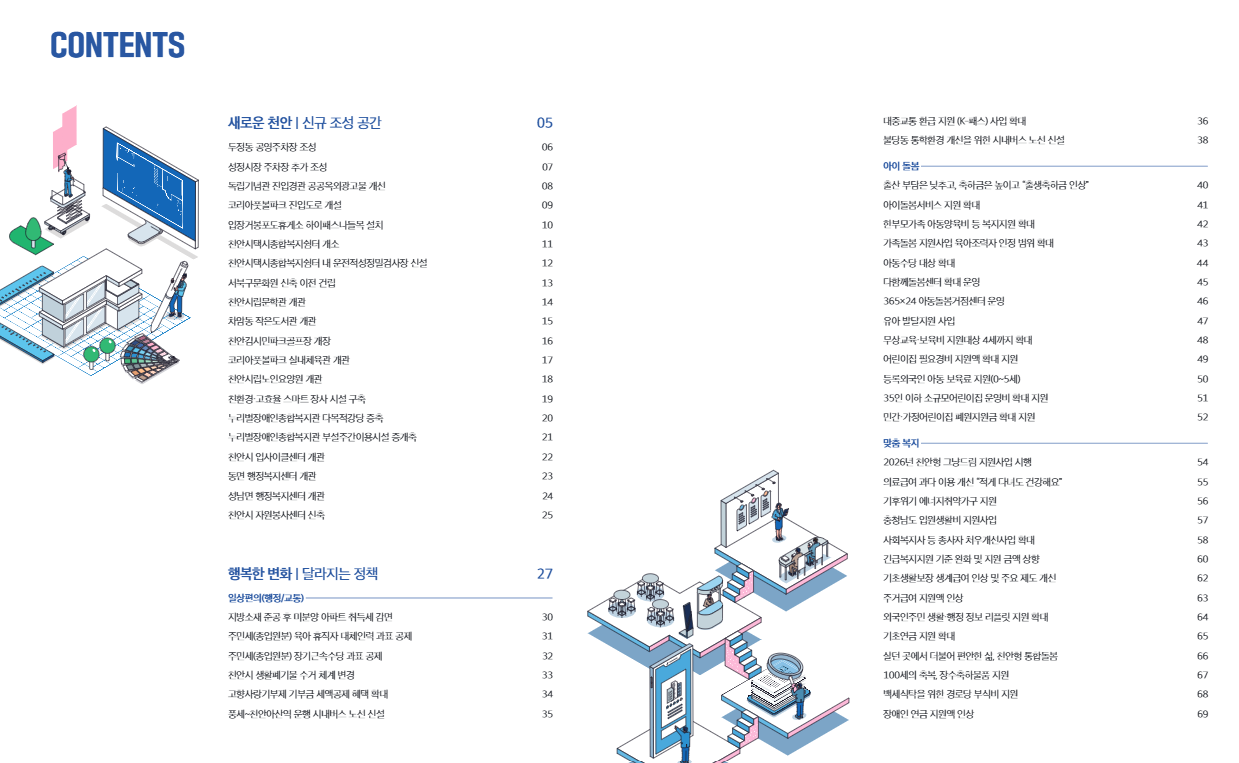

**3페이지의 좌측 내용**

In [26]:
print(f"\n문서 메타데이터: {docs_change[2].metadata}")
print(f"문서 길이: {len(docs_change[2].page_content)}자")
print(f"\n문서 내용 샘플:\n{docs_change[2].page_content}")


문서 메타데이터: {'source': '2026 달라지는 천안 새로운 변화.pdf', 'page': 3, 'sub_page': 'left'}
문서 길이: 2127자

문서 내용 샘플:
CONTENTS




               새로운 천안 | 신규 조성 공간                   05

                     두정동 공영주차장 조성                                        06

                     성정시장 주차장 추가 조성                                       07

                     독립기념관 진입경관 공공옥외광고물 개선                           08

                     코리아풋볼파크 진입도로 개설                                   09

                     입장거봉포도휴게소 하이패스나들목 설치                            10

                     천안시택시종합복지쉼터 개소                                    11

                     천안시택시종합복지쉼터 내 운전적성정밀검사장 신설                    12

                     서북구문화원 신축 이전 건립                                    13

                     천안시립문학관 개관                                          14

                     차암동 작은도서관 개관                                        15

                     천안김시민파크골프장 개장                                     16

 

**3페이지의 우측 내용**

In [27]:
print(f"\n문서 메타데이터: {docs_change[3].metadata}")
print(f"문서 길이: {len(docs_change[3].page_content)}자")
print(f"\n문서 내용 샘플:\n{docs_change[3].page_content}")


문서 메타데이터: {'source': '2026 달라지는 천안 새로운 변화.pdf', 'page': 3, 'sub_page': 'right'}
문서 길이: 1609자

문서 내용 샘플:
대중교통 환급 지원 (K-패스) 사업 확대                              36

불당동 통학환경 개선을 위한 시내버스 노선 신설                       38


아이 돌봄

출산 부담은 낮추고, 축하금은 높이고 “출생축하금 인상”                   40

아이돌봄서비스 지원 확대                                       41

한부모가족 아동양육비 등 복지지원 확대                             42

가족돌봄 지원사업 육아조력자 인정 범위 확대                         43

아동수당 대상 확대                                          44

다함께돌봄센터 확대 운영                                      45

365×24 아동돌봄거점센터 운영                                  46

유아 발달지원 사업                                           47

무상교육·보육비 지원대상 4세까지 확대                             48

어린이집 필요경비 지원액 확대 지원                                49

등록외국인 아동 보육료 지원(0~5세)                               50

35인 이하 소규모어린이집 운영비 확대 지원                          51

민간·가정어린이집 폐원지원금 확대 지원                             52


맞춤 복지

2026년 천안형 그냥드림 지원사업 시행                             54



### 6-3. 벡터스토어에 추가

In [28]:
from uuid import uuid4

# 문서 추가
vectorstore.add_documents(documents=docs_change)

print(f"\n{len(docs_change)}개의 문서가 벡터스토어에 추가되었습니다.")

# 전체 문서 수 확인
collection_info = client.get_collection(collection_name)
print(f"벡터스토어에 저장된 총 문서 수: {collection_info.points_count}")


93개의 문서가 벡터스토어에 추가되었습니다.
벡터스토어에 저장된 총 문서 수: 516


### 6-4. 통합 검색 테스트

In [29]:
query = "두정동 공영주차장"

results = vectorstore.similarity_search(query, k=5)

print(f"검색 쿼리: {query}")
print(f"검색 결과: {len(results)}개의 문서 반환\n")

for i, result in enumerate(results, start=1):
    print(f"\n[관련 문서 {i}]")
    print(f"출처: {result.metadata.get('source', '?')}")
    print(f"페이지: {result.metadata.get('page', '?')}")
    if 'sub_page' in result.metadata:
        print(f"위치: {result.metadata.get('sub_page', '?')}")
    print(f"내용: {result.page_content}")
    print("-" * 80)

검색 쿼리: 두정동 공영주차장
검색 결과: 5개의 문서 반환


[관련 문서 1]
출처: 2026 달라지는 천안 새로운 변화.pdf
페이지: 5
위치: left
내용:                                                  개장일 | 2026. 06. 예정

 두정동 공영주차장 조성

 두정동 먹자골목에 시민을 위한 공영주차장이 들어섭니다.





새롭게          위  치 서북구 두정동 849번지 일원
만들어요         주요시설  공영주차장(138면) 개설

              준공시기  2026. 06. 예정




더 자세히         •주차 공간 확보로 두정동 주차난 해소 | 편리한 주차, 친환경 주차!
알려드립니다       •교통 편의성이 높아져 주민들의 이동 편의성 증진 | 더 나은 교통, 행복한 지역!

              •불법 주정차 감소로 두정동 먹자골목 환경 개선 | 쾌적한 환경, 넉넉한 공간!

              •접근성 및 이동 편의성 증진으로 지역 경제 활성화 | 주차 걱정 끝, 경제 활력 시작!





담당부서         •교통정책과 주차장조성팀 041-521-5887





6
--------------------------------------------------------------------------------

[관련 문서 2]
출처: 2026 주요업무계획.pdf
페이지: 236
내용: Ⅴ 공영주차장 유료운영 확대                       신규

 사 업 개 요

❍  ( 사업기간 ) 2026. 1. ~ 2026. 6.

❍  ( 사 업 비) 250백만원 ( 시비)

❍  ( 대 상 지)

    구 분        위 치     면 적(㎡ )  면 수   관리주체

 청당 제공영주차장2        청당동 567 번지      727       27
                                 천안 도시공사
 불당 제

## 7. 통합 RAG 답변 생성

In [31]:
question = "빵 축제는 언제 열려요?"
answer = rag_answer(question, k=5)

print(f"질문: {question}\n")
display(Markdown(answer))

검색된 문서 컨텍스트:
[출처: 2026 주요업무계획.pdf, 페이지: 214]
Ⅰ 복합문화축제로 도약하는 「2026 빵빵데이 천안」    핵심  계속

 사 업 개 요

❍  ( 사업기간 ) 2026. 1. ~ 12.
❍  ( 사 업 비) 450백만원 ( 도비100 시비 350)
❍  ( 주요내용 )
 - 제과업계 및 지역 농축산기업대학이,         ,    함께 만들어가는 빵산업 기반 구축
 - 천안의 우수한 빵 자원을 기반으로 문화관광과 연계한‘빵빵데이 천안’개최

 추 진 계 획

❍ 관광외식숙박,         ,   등과 연계된 ‘ 빵지순례 모바일 스탬프투어’ 개발
  - 사한국외식업중앙회천안시지부사대한숙박업중앙회천안시지회)                                                ,     )             등과 상생 협업
❍ ‘ 빵빵데이 천안 ’과 MICE 연계를 통한 축제 발전 방안 모색
 -‘ 빵의 도시 천안 ’의 역사와 정체성비전,   등 추구
  - 세미나 등을 통해 지역 산업 플랫폼으로 발전할 방안 강구
❍ 베이커리 경연대회 등 지역 산 · 학 ·연과 고품질 제과기술 발전방안 마련
❍ 세계 각국의 명품 빵을 소개하는 글로벌 베이커리 축제 확대 방안 모색
❍ 시민과 함께 공공적 가치 및 의미를 공유할 수 있도록 사회환원 사업 추구

 기 대 효 과

❍ 천안만의 차별화된 빵축제 개최로  ‵빵의도시 천안 ′ 의 브랜드 확립
❍지역산업 연계 강화를 통한 축제 지속가능성 확보 및 지역 경제 활성화 이바지

Ⅱ가족과 함께하는 “ 쌀맛나는 천안삼거리 떡 페스티벌 ”     핵심  계속

 사 업 개 요

❍  ( 사업기간 ) 2026. 7. ~ 12.
❍  ( 사 업 비) 30백만원 ( 도비15 시비 15)
❍  ( 주요내용 )
 - 전통먹거리떡(  )+지역농산물쌀(  )+체험・놀이가족(      ) 결합한 가족친화형 축제

 추 진 계 획

❍ 건강한 식품 떡 홍보 확대 및 올해 참여자 피드백 반영
❍ 떡류

빵 축제인 **「2026 빵빵데이 천안」은 2026년 10월 17일(토)부터 10월 18일(일)까지** 열립니다.  
행사 장소는 **천안종합운동장 오륜문광장 일원**으로 안내되어 있습니다.  

참고로, **2026 달라지는 천안 새로운 변화** 자료에는 **6월 13일(토)~14일(일)**에 **“빵지순례 빵빵데이”**가 별도로 표기되어 있어, 관련 사전행사 또는 연계행사로 보입니다.

**출처**
- 2026 달라지는 천안 새로운 변화.pdf, **페이지 51**
- 2026 달라지는 천안 새로운 변화.pdf, **페이지 50**

### 7-1. 다양한 질문으로 테스트

In [32]:
# 테스트할 질문 목록
test_questions = [
    "천안시의 교통 개선 계획은?",
    "천안시 복지 정책에 대해 알려주세요",
    "두정동 공영주차장 건설 일정은 어떻게 되나요?",
    "천안 웹툰 공모전 정보 알려주세요."
]

for i, q in enumerate(test_questions, start=1):
    print(f"\n{'='*80}")
    print(f"질문 {i}: {q}")
    print('='*80)

    answer = rag_answer(q, k=3)
    display(Markdown(answer))


질문 1: 천안시의 교통 개선 계획은?
검색된 문서 컨텍스트:
[출처: 2026 주요업무계획.pdf, 페이지: 221]
 0 1 정책여건

 최근 국가 재정 여건의 악화로 정부예산이 효율성 중심으로 재편되고
 있어선택과,    집중을 통한 실효성 높은 사업 발굴 필요

전 세계적 기후 위기의 심화로 폭염·집중호우·지진 등 복합 재난 발생이
 늘어나면서 사전 예방 중심의 통합 안전 체계 강화가 절실한 상황

 ‘100만 미래도시 천안’실현을 위한 도시 개발이 본격화됨에 따라교통,
 수요 증가와 도시 인프라 노후화 대응교통약자를,      위한 인프라 확충, 전략
 사업의 안정적 계승 및 신속한 추진 필요

아울러스마트시티,         ·ITS 등 디지털 기반의 도시관리탄소중립,     및 친환경
 교통 확대, 광역교통망 조성 등 신 교통체계에 대한 시민 요구가 커져
 디지털·친환경 중심 정책 전환 가속화

이러한 변화에 선제적으로 대응하기 위한 실효성 있는 사업을 추진하고
 안전하고 편리한 도시 기반 조성을 위한 체계적 정책 마련이 필요한 시점

 0 2 정책추진방향

 천안형 도로망 확대 및 도시 내 ·외부 교통연계를 강화하여 지역 균형
 발전을 선도할 교통망 조성

재난 위험의 선제적 예측 및 체계적인 재난 대응 시스템 마련으로 시민
 안전 기반 확립

 대중교통의 편리성과 접근성을 높이기 위해 스마트 기술을 접목한 교통
 서비스 제공 및 친환경 교통수단 확대

효율적인 교통운영을 위한 스마트 교통서비스 도입 및 시민 체감형 교통
 서비스 구현

하천의 치수·이수 관리 강화 및 안전한 수변환경 조성으로 시민들의 삶의
 질을 높이는 지속 가능한 친수공간 확대

                                               - 219 -

---

[출처: 2026 주요업무계획.pdf, 페이지: 223]
정책
목표      시민의 삶을 바꾸는 미래형 도로 도시




  세부전략
❍ 100만 대도시 광역 도로망 구축


천안시의 교통 개선 계획은 **미래형 도로망 구축, 스마트·친환경 교통체계 확대, 생활밀착형 교통환경 개선**을 중심으로 추진됩니다.

### 1) 광역 도로망과 도시 연결 강화
- **천안형 도로망 확대**
- 도시 **내·외부 교통연계 강화**
- 100만 대도시를 대비한 **광역 도로망 구축**
- 주요 사업 예:
  - 성황동~불당동 연결도로 신설 및 확장
  - 오곡리 도로개설
  - 풍세로·신방풍세 도로확장
  - 망향로 개선사업
  - 흑성산로 도로개설

### 2) 안전하고 쾌적한 도로환경 조성
- 재난 위험 대응과 함께 **안전한 도로 기반** 마련
- 보행 안전과 편의 개선
- 주요 사업 예:
  - 삼성 SDI 앞 보행육교 설치
  - 자전거 친화도시 조성
  - 둘레길 300리 조성 마무리

### 3) 스마트·친환경 교통체계 도입
- **AI·스마트 기술 기반 교통관리**
- 대중교통의 편리성과 접근성 향상
- 친환경 교통수단 확대
- 주요 사업 예:
  - AI 신호제어 꼬리물기 차단 시스템 설치
  - 스쿨존 스마트 보행안전장치 설치
  - 탄소중립 보행환경 개선 사업

### 4) 대중교통 및 철도망 확충
- 지역 경제와 연계한 교통망 구축
- 철도 교통망 강화
- 주요 사업 예:
  - 천안역 증개축
  - GTX-C 노선 천안 연장
  - 부성역 신설
  - 중부권 동서횡단철도 건설
  - 수도권전철 독립기념관 연장 및 청수역 신설
  - 철도 정기승차권 교통비 지원

### 5) 주차·보행·교통안전 개선
- **공영주차장 관리 효율화 및 확충**
- 보행환경 개선과 교통안전 문화 확산
- 주요 사업 예:
  - 공영주차장 유료운영 확대
  - 공영주차장 확충
  - 고령자 운전면허 자진반납 지원
  - 보행안전지도원 운영

### 요약
천안시는 **도로망 확충, 스마트교통 도입, 철도·대중교통 강화, 보행 및 주차환경 개선**을 통해 시민이 더 **안전하고 편리하게 이동할 수 있는 도시**를 만들 계획입니다.

**출처:**  
- 2026 주요업무계획.pdf, **p.221** (정책여건 및 정책추진방향)  
- 2026 주요업무계획.pdf, **p.223** (미래형 도로 도시 주요업무)  
- 2026 주요업무계획.pdf, **p.233** (생활밀착형 교통환경 개선 주요업무)


질문 2: 천안시 복지 정책에 대해 알려주세요
검색된 문서 컨텍스트:
[출처: 2026 주요업무계획.pdf, 페이지: 297]
정책
목표     시민 모두가 누리는 행복한 건강도시 천안




  세부전략
❍ 취약계층 건강관리를 통한 건강 형평성 제고
❍ 출산과 양육 친화적 환경 조성
❍ 생애주기별 맞춤형 건강증진 서비스 지원
❍ 인식개선과 편견 해소를 통한 건강친화도시 구현




  주요업무

❶ 핵심함께 행복한 이 (爾) 웃음저소득층-     치과 의료비 지원
❷ 핵심데이터 기반 건강정책 , 「지역사회 건강조사 」
❸ 신규천안형 가임력 보존 지원
❹ 계속좋은 이웃과 함께 만드는 「생명존중 안심마을」
❺ 계속매일 뇌 톡톡, 인지 점핑 업!
❻ 계속할머니, 할아버지를 빼앗아간 「 기억 도둑을 잡아라!」
❼ 계속움직이는 천안, 건강한 시민





                                               - 295 -

---

[출처: 2026 달라지는 천안 새로운 변화.pdf, 페이지: 31]
더 자세히         •지원대상 | 관내 사회복지시설 등 종사자
알려드립니다        ※ 사업별 지원대상 상이

              •지원내용


                      구분                    내용

                       장기근속휴가  •3년 이상 근속자 장기근속 휴가 부여(3일~15일 차등)

                              •(난임치료시술 휴가) 여성 2~4일, 남성 1일
                 근무환경 가족친화 특별휴가
                                   •(임신검진 휴가) 임신기간 중 10일
                 개선
                              •반기별 총량범위 내 개인별 시간외근무수당 탄력 운영·적용
                      시간외근무 총량제
           

천안시의 복지 정책은 **취약계층 지원, 출산·양육 친화 환경 조성, 생애주기별 건강증진, 건강친화도시 구현**을 중심으로 추진되고 있습니다.  
핵심 방향은 시민 모두가 건강하고 행복한 도시를 만드는 데 있습니다.

### 주요 복지·보건 정책
1. **저소득층 치과 의료비 지원**
   - 취약계층의 구강건강을 돕는 사업입니다.

2. **지역사회 건강조사 기반 건강정책 추진**
   - 데이터에 기반해 지역 맞춤형 건강정책을 마련합니다.

3. **천안형 가임력 보존 지원**
   - 출산과 양육 친화적 환경을 조성하기 위한 신규 사업입니다.

4. **생명존중 안심마을**
   - 자살예방 등 생명존중 문화 확산을 위한 사업입니다.

5. **인지 건강 프로그램**
   - 예: “매일 뇌 톡톡, 인지 점핑 업!”, “기억 도둑을 잡아라!” 같은 인지기능 향상 프로그램 운영

6. **신체활동 활성화**
   - “움직이는 천안, 건강한 시민”처럼 시민의 건강생활 실천을 지원합니다.

### 정책의 큰 방향
- **취약계층 건강관리로 건강 형평성 제고**
- **출산과 양육 친화적 환경 조성**
- **생애주기별 맞춤형 건강증진 서비스 지원**
- **인식개선과 편견 해소를 통한 건강친화도시 구현**

### 참고한 문서
- **2026 주요업무계획.pdf**, **297페이지**
  - 천안시 정책 목표 및 세부전략, 주요업무 내용

원하시면 제가 이어서 **천안시의 복지 예산/사업별 세부내용**이나 **노인·아동·저소득층 대상 복지사업**만 따로 정리해드릴게요.


질문 3: 두정동 공영주차장 건설 일정은 어떻게 되나요?
검색된 문서 컨텍스트:
[출처: 2026 달라지는 천안 새로운 변화.pdf, 페이지: 5]
                                                 개장일 | 2026. 06. 예정

 두정동 공영주차장 조성

 두정동 먹자골목에 시민을 위한 공영주차장이 들어섭니다.





새롭게          위  치 서북구 두정동 849번지 일원
만들어요         주요시설  공영주차장(138면) 개설

              준공시기  2026. 06. 예정




더 자세히         •주차 공간 확보로 두정동 주차난 해소 | 편리한 주차, 친환경 주차!
알려드립니다       •교통 편의성이 높아져 주민들의 이동 편의성 증진 | 더 나은 교통, 행복한 지역!

              •불법 주정차 감소로 두정동 먹자골목 환경 개선 | 쾌적한 환경, 넉넉한 공간!

              •접근성 및 이동 편의성 증진으로 지역 경제 활성화 | 주차 걱정 끝, 경제 활력 시작!





담당부서         •교통정책과 주차장조성팀 041-521-5887





6

---

[출처: 2026 주요업무계획.pdf, 페이지: 286]
Ⅴ 불당 제공영주차장2      주차타워 건립공사              신규

 사 업 개 요

❍  ( 사업기간 ) 2023. 4. ~ 2027. 9.

❍  ( 위  치) 서북구 불당동 735번지

❍  ( 사 업 비) 13,000백만원( 도비6,400 시비6,600)

❍  ( 사 업 량) 연면적 5,500㎡(지상 5층, 6단 / 주차 170대)

❍  ( 주요내용 ) 자동차관련시설주차장(          )

 추 진 계 획

❍ 실시설계 (‘25. 10) ➠ 착공 (‘26. 6.) ➠ 준공 (‘27. 9.)

 기 대 효 과

❍ 공영주차장 건립으로 주차난 해소 및 지역경제 활성화 도모


Ⅵ 남부권 시내버스 공영차고지 조성

두정동 공영주차장은 **2026년 6월 준공 예정**입니다.  
즉, **개장일(준공시기)은 2026. 06. 예정**으로 안내되어 있습니다. 두정동 먹자골목 인근에 **공영주차장 138면**이 조성됩니다.

- **출처:** *2026 달라지는 천안 새로운 변화.pdf*  
- **페이지:** 5쪽




질문 4: 천안 웹툰 공모전 정보 알려주세요.
검색된 문서 컨텍스트:
[출처: 2026 달라지는 천안 새로운 변화.pdf, 페이지: 45]
                                                 시행일 2026. 06. 예정


 천안 K-웹툰                천안에서 만나는 웹툰의 미래,
                                   『천안 K-웹툰 공모전』을 개최합니다.
 공모전 개최





새롭게            우수 웹툰 인재 발굴! 천안 K-웹툰 공모전 개최
시작해요         •전국 단위 웹툰 공모를 통한 우수 창작자 발굴

              •K-컬쳐 박람회 연계 우수작품 전시




더 자세히         •주요내용
알려드립니다                - 학생부 / 일반부 구분 웹툰 공모전 운영(전국단위 모집)

                              - K-컬쳐 박람회 연계 우수작품 시상식 개최 및 수상작 전시

              •시상규모 | 80명(학생부 40명, 일반부 40명)

              •운영일정


                  공모전홍보       작품접수         심사          시상·전시


                             2026. 04.~05.         2026. 06.~08.           2026. 08.             2026. 09.



              •접수방법 | 이메일 접수(충남콘텐츠진흥원)

               ※ 1인 3작품 이내

              •주최/주관 | 충남콘텐츠진흥원 AI콘텐츠본부

              •문의 | 041-590-0944




담당부서         문화예술과 문화산업팀 041-521-5154





86

---

[출처: 2026 주요업무계획.pdf, 페이지: 160]
Ⅰ  천안문

천안 웹툰 공모전은 **「천안 K-웹툰 공모전」**입니다.  
주요 내용은 아래와 같습니다.

- **사업명:** 천안 K-웹툰 공모전 개최
- **사업기간:** 2026. 4. ~ 11.
- **대상:** **학생부 / 일반부**로 구분하여 전국 단위 모집
- **시상규모:** **총 80명**  
  - 학생부 40명  
  - 일반부 40명
- **주요내용:**  
  - 전국 단위 웹툰 공모를 통해 우수 창작자 발굴  
  - **K-컬쳐 박람회 연계** 우수작품 시상식 및 전시
- **접수방법:** **이메일 접수(충남콘텐츠진흥원)**
- **출품 제한:** **1인 3작품 이내**
- **운영일정:**  
  - 공모전 홍보: **2026. 4.~5.**  
  - 작품 접수: **2026. 6.~8.**  
  - 심사: **2026. 8.**  
  - 시상·전시: **2026. 9.**
- **주최/주관:** 충남콘텐츠진흥원 AI콘텐츠본부
- **문의:** **041-590-0944**
- **담당부서:** 문화예술과 문화산업팀 **041-521-5154**

참고로, 주요업무계획에는 이 사업의 목적이  
- 지역 웹툰 산업 기반 조성  
- 청년 창작인재 육성  
- 2026년 K-컬쳐박람회와 연계한 작품 홍보·전시  
로 정리되어 있습니다.

**출처**
- **2026 달라지는 천안 새로운 변화.pdf**, **45페이지**
- **2026 주요업무계획.pdf**, **160페이지**

원하시면 제가 이 공모전 정보를 **접수 일정 중심으로 다시 정리**해드리거나, **응모 시 유의사항만 따로 요약**해드릴게요.

## 📖 과제 1: 프롬프트 최적화

프롬프트 템플릿을 수정하여 답변 품질을 개선해보세요.

**개선 요소:**
1. 역할 정의 강화
2. 답변 형식 지정 (불렛 포인트, 번호 목록 등)
3. 출처 표시 요구
4. 제약 조건 명시

In [34]:
from datetime import datetime
from langchain_core.prompts import PromptTemplate
from IPython.display import Markdown, display

current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# 개선된 프롬프트 템플릿
improved_template = """
당신은 천안시의 행정, 정책, 지역개발 사업을 분석하는 정책 전문가입니다.
사용자의 질문에 대해 반드시 제공된 문서의 내용만을 근거로
정확하고 구체적으로 답변하세요.

<현재 시각>
{current_time}
</현재 시각>

다음 규칙을 반드시 따르세요.

1. 답변 형식
- 먼저 핵심 내용을 2~3문장으로 요약하세요.
- 이후 주요 내용을 번호 목록 또는 불렛 포인트로 정리하세요.
- 여러 사업이 있다면 사업별로 구분해서 설명하세요.

2. 출처 표시
- 답변의 주요 내용에는 근거가 된 문서의 출처와 페이지를 표시하세요.
- 예: [출처: 천안시 주요업무계획.pdf, p.15]
- 제공된 출처 정보가 없는 경우 임의로 만들어내지 마세요.

3. 제약 조건
- 반드시 <context>에 제공된 정보만 사용하세요.
- 문서에 존재하지 않는 내용은 추측하거나 외부 지식을 사용하지 마세요.
- 필요한 정보가 문서에서 확인되지 않으면
  "제공된 문서에는 해당 정보가 없습니다."라고 명확하게 답변하세요.
- 서로 다른 문서의 내용을 임의로 합쳐 사실처럼 표현하지 마세요.

4. 구체성
- 사업명, 날짜, 예산, 인원, 지역, 목표 수치 등
  구체적인 정보가 문서에 있다면 반드시 포함하세요.
- 숫자나 날짜를 임의로 변경하거나 추정하지 마세요.

<context>
{context}
</context>

<question>
{question}
</question>

위 규칙에 따라 답변하세요.
"""

improved_prompt_template = PromptTemplate(
    input_variables=["current_time", "context", "question"],
    template=improved_template
)


# 개선된 프롬프트 기반 RAG 함수
def rag_answer_improved(question: str, k: int = 3) -> str:

    # 1. 질문과 유사한 문서 검색
    retrieved_docs = vectorstore.similarity_search(
        question,
        k=k
    )

    # 2. 검색된 문서 + 출처 정보 구성
    context_parts = []

    for doc in retrieved_docs:
        source = doc.metadata.get("source", "출처 정보 없음")
        page_num = doc.metadata.get("page", "페이지 정보 없음")

        context_parts.append(
            f"[출처: {source}, 페이지: {page_num}]\n"
            f"{doc.page_content}"
        )

    context = "\n\n---\n\n".join(context_parts)

    # 3. 프롬프트 생성
    formatted_prompt = improved_prompt_template.format(
        current_time=current_time,
        context=context,
        question=question
    )

    # 4. LLM 호출
    response = llm.invoke(formatted_prompt)

    return response.content


# 테스트
question = "천안시의 빵 축제 일정에 대해서 알려줘"

answer = rag_answer_improved(
    question,
    k=4
)

print(f"질문: {question}\n")
display(Markdown(answer))

질문: 천안시의 빵 축제 일정에 대해서 알려줘



천안시의 빵 축제는 문서상 **두 가지 일정**이 확인됩니다. 하나는 **2026 빵지순례 빵빵데이(6월)**, 다른 하나는 **2026 빵빵데이 천안(10월)**입니다. 각 축제는 개최 시기와 장소가 문서에 제시되어 있으며, 특히 10월 행사는 복합문화축제로 도약하는 방향으로 추진됩니다. [출처: 2026 달라지는 천안 새로운 변화.pdf, p.50; 2026 주요업무계획.pdf, p.213, p.214]

1. **2026 빵지순례 빵빵데이**
   - **일정:** 2026. 06. 13.(토) ~ 14.(일)
   - **장소:** 시청 버들광장, 시청 로비 등
   - **비고:** 장소는 추후 변동 가능
   - [출처: 2026 달라지는 천안 새로운 변화.pdf, p.50]

2. **2026 빵빵데이 천안**
   - **일정:** 2026. 10. 17.(토) ~ 18.(일)
   - **장소:** 천안종합운동장 오륜문광장 일원
   - **사업기간:** 2026. 1. ~ 12.
   - **사업비:** 450백만원(도비 100, 시비 350)
   - **주요내용:** 천안의 우수한 빵 자원을 기반으로 문화관광과 연계한 축제 개최
   - [출처: 2026 달라지는 천안 새로운 변화.pdf, p.51; 2026 주요업무계획.pdf, p.214]

3. **추가로 확인되는 추진 방향**
   - ‘빵지순례 모바일 스탬프투어’ 개발
   - ‘빵빵데이 천안’과 MICE 연계를 통한 축제 발전 방안 모색
   - 베이커리 경연대회 등 지역 산·학·연과 연계한 고품질 제과기술 발전방안 마련
   - 글로벌 베이커리 축제 확대 방안 모색
   - [출처: 2026 주요업무계획.pdf, p.214]

원하시면 제가 이어서 **빵빵데이 천안의 사업개요·추진계획·기대효과**까지 문서 기준으로 정리해드릴게요.

---

### 참고 자료

- [Qdrant 공식 문서](https://qdrant.tech/documentation/)
- [LangChain Qdrant 통합](https://python.langchain.com/docs/integrations/vectorstores/qdrant/)
- [LangChain Prompts 공식 문서](https://python.langchain.com/docs/modules/model_io/prompts/)
- [PyMuPDF 문서](https://pymupdf.readthedocs.io/)